## LSTM ON YAHOO FINANCE

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
# 1. Fetch Apple stock data (2 years, daily interval)
df = yf.download('AAPL', period="2y", interval="1d")

# 2. Keep only the 'Close' column and drop missing values
df = df[['Close']].dropna()

# 3. Train-test split (no shuffle, chronological order)
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

[*********************100%***********************]  1 of 1 completed

Train size: 400
Test size: 101


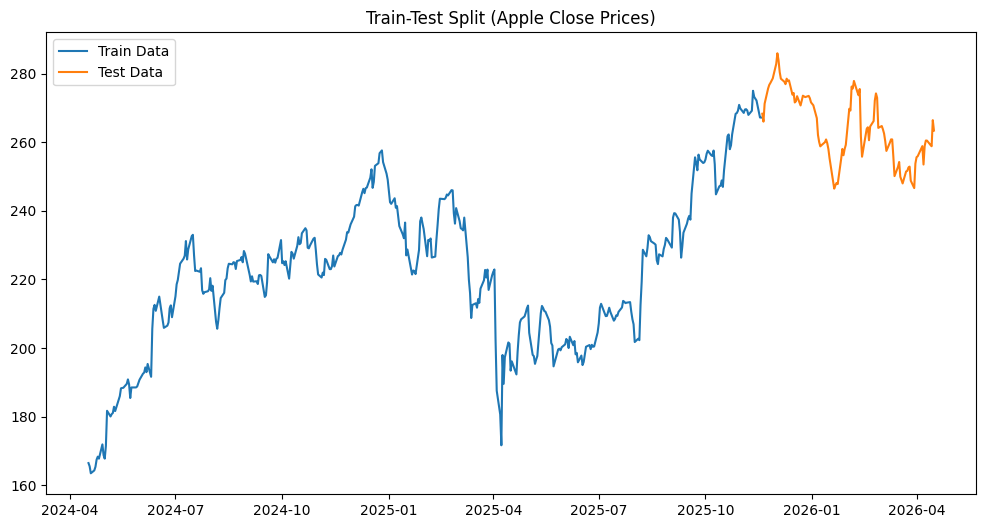

In [3]:
# 4. Plot to confirm split
plt.figure(figsize=(12,6))
plt.plot(train_data.index, train_data['Close'], label="Train Data")
plt.plot(test_data.index, test_data['Close'], label="Test Data")
plt.legend()
plt.title("Train-Test Split (Apple Close Prices)")
plt.show()

In [4]:
import seaborn as sns

# Basic info
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 501 entries, 2024-04-17 to 2026-04-16
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  501 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB
None
Price        Close
Ticker        AAPL
count   501.000000
mean    230.381934
std      26.827279
min     163.511902
25%     211.685806
50%     227.545273
75%     253.107376
max     285.922455


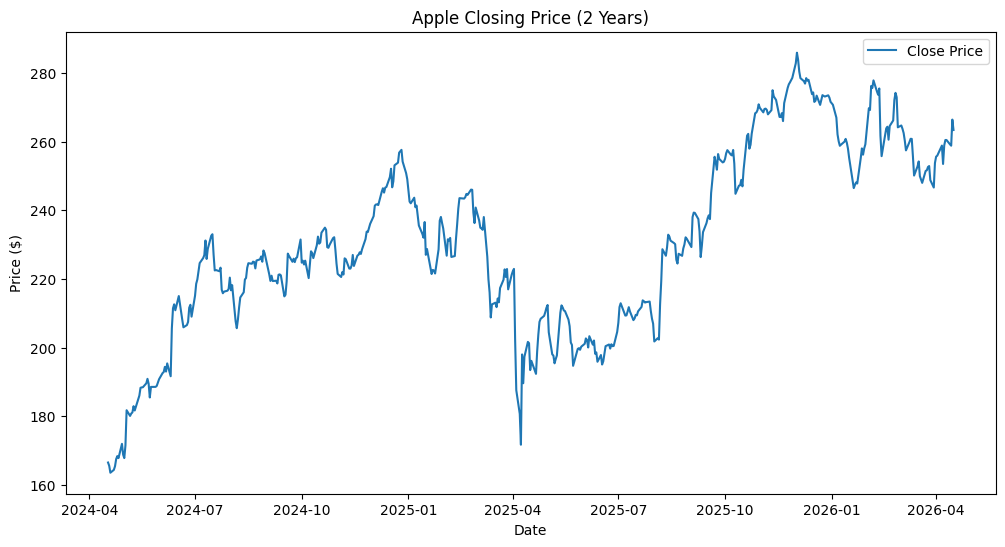

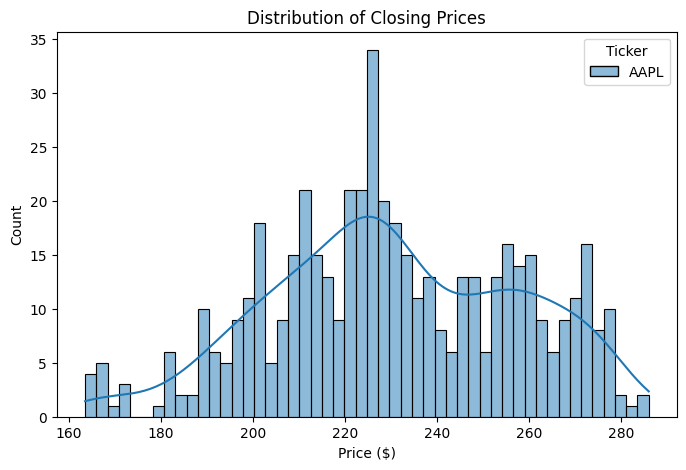

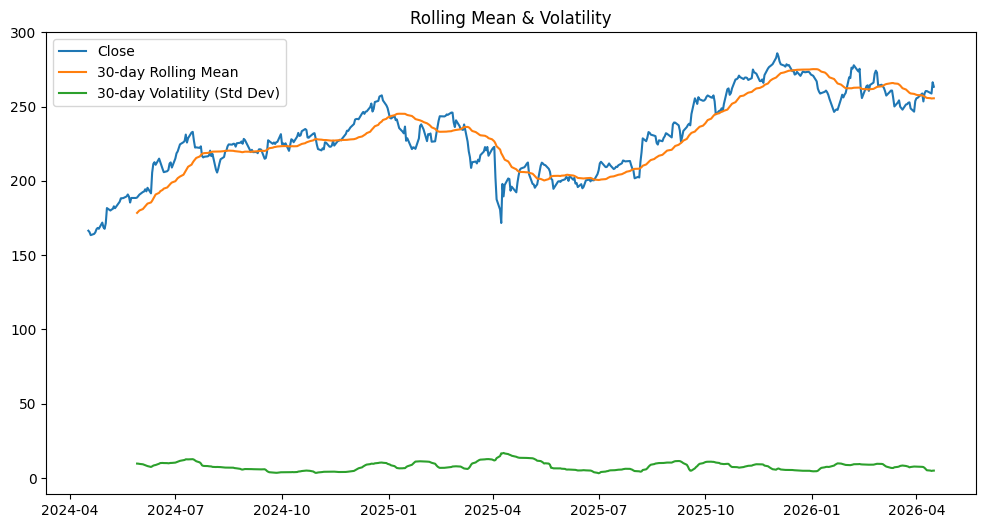

In [5]:
# 1. Plot closing price over time
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title("Apple Closing Price (2 Years)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

# 2. Distribution of closing prices
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Price ($)")
plt.show()

# 3. Rolling mean and volatility
df['RollingMean'] = df['Close'].rolling(window=30).mean()
df['RollingStd'] = df['Close'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['RollingMean'], label='30-day Rolling Mean')
plt.plot(df['RollingStd'], label='30-day Volatility (Std Dev)')
plt.title("Rolling Mean & Volatility")
plt.legend()
plt.show()

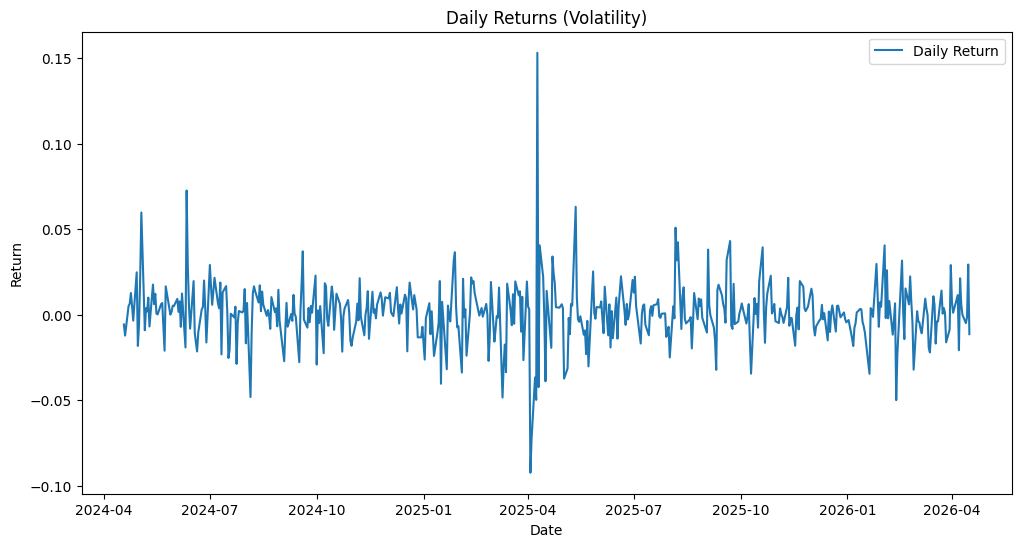

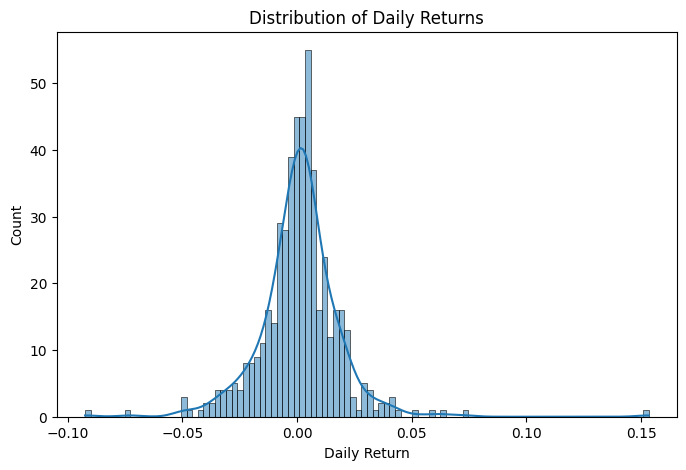

In [6]:
# 4. Daily returns
df['DailyReturn'] = df['Close'].pct_change()

plt.figure(figsize=(12,6))
plt.plot(df['DailyReturn'], label='Daily Return')
plt.title("Daily Returns (Volatility)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

# 5. Histogram of daily returns
plt.figure(figsize=(8,5))
sns.histplot(df['DailyReturn'].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

[*********************100%***********************]  1 of 1 completed


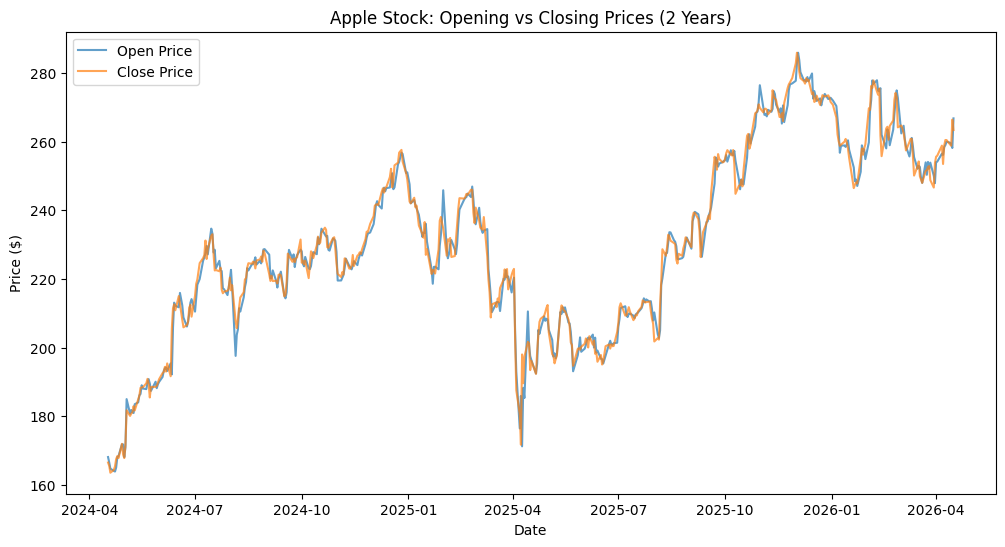

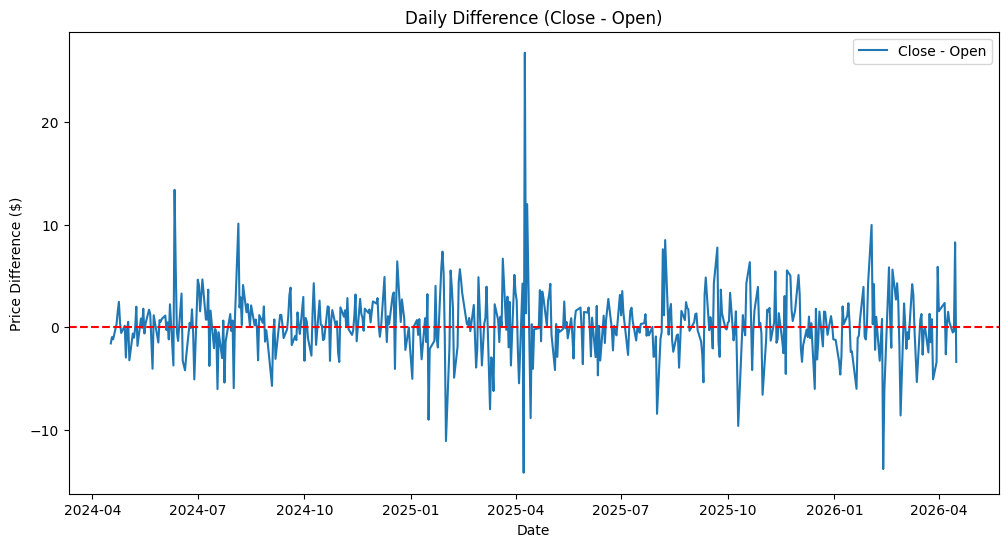

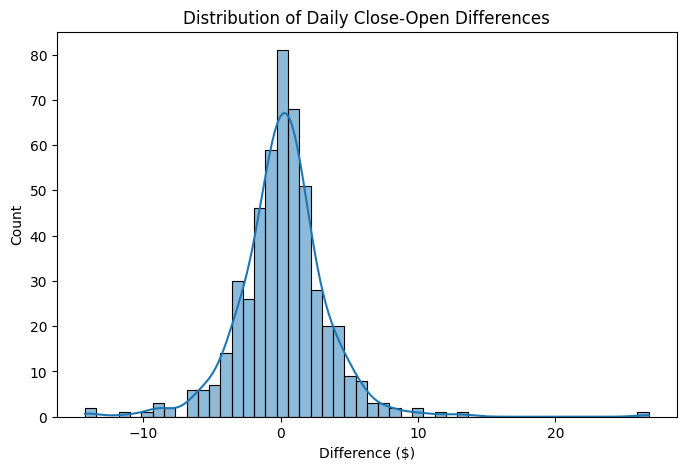

count    501.000000
mean       0.191367
std        3.304064
min      -14.218031
25%       -1.352612
50%        0.238439
75%        1.639226
max       26.783278
Name: Diff, dtype: float64


In [7]:
# Fetch data again with Open and Close
df_oc = yf.download('AAPL', period="2y", interval="1d")
df_oc = df_oc[['Open','Close']].dropna()

# 1. Plot Open vs Close over time
plt.figure(figsize=(12,6))
plt.plot(df_oc.index, df_oc['Open'], label='Open Price', alpha=0.7)
plt.plot(df_oc.index, df_oc['Close'], label='Close Price', alpha=0.7)
plt.title("Apple Stock: Opening vs Closing Prices (2 Years)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

# 2. Difference between Close and Open
df_oc['Diff'] = df_oc['Close'] - df_oc['Open']

plt.figure(figsize=(12,6))
plt.plot(df_oc.index, df_oc['Diff'], label='Close - Open')
plt.axhline(0, color='red', linestyle='--')
plt.title("Daily Difference (Close - Open)")
plt.xlabel("Date")
plt.ylabel("Price Difference ($)")
plt.legend()
plt.show()

# 3. Distribution of differences
plt.figure(figsize=(8,5))
sns.histplot(df_oc['Diff'], bins=50, kde=True)
plt.title("Distribution of Daily Close-Open Differences")
plt.xlabel("Difference ($)")
plt.show()

# 4. Quick stats
print(df_oc['Diff'].describe())

In [8]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [9]:
def create_dataset(dataset, seq_length=60):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:(i + seq_length), 0])
        y.append(dataset[i + seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_dataset(train_scaled, seq_length)
X_test, y_test = create_dataset(test_scaled, seq_length)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (340, 60)
X_test shape: (41, 60)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Prepare data for training
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

# Quick training loop
model.train()
for epoch in range(20):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/20], Loss: {loss.item():.4f}')

Epoch [5/20], Loss: 0.2738
Epoch [10/20], Loss: 0.1801
Epoch [15/20], Loss: 0.0746
Epoch [20/20], Loss: 0.0494


In [11]:
# Example model (SimpleNet)
class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# Dummy dataset
X_dummy = torch.randn(200, 10)
y_dummy = torch.randn(200, 1)

# Initialize model
model_simple = SimpleNet(input_size=10, hidden_size=32, output_size=1)
loss_fn = nn.MSELoss()
optimizer_simple = optim.Adam(model_simple.parameters(), lr=0.001)

for epoch in range(10):
    outputs = model_simple(X_dummy)
    loss = loss_fn(outputs, y_dummy)
    optimizer_simple.zero_grad()
    loss.backward()
    optimizer_simple.step()
    print(f"Epoch [{epoch+1}/10], Loss: {loss.item():.4f}")

Epoch [1/10], Loss: 0.9233
Epoch [2/10], Loss: 0.9152
Epoch [3/10], Loss: 0.9073
Epoch [4/10], Loss: 0.8998
Epoch [5/10], Loss: 0.8926
Epoch [6/10], Loss: 0.8858
Epoch [7/10], Loss: 0.8792
Epoch [8/10], Loss: 0.8730
Epoch [9/10], Loss: 0.8671
Epoch [10/10], Loss: 0.8615


In [12]:
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

with torch.no_grad():
    y_pred_tensor = model(X_test_t)

y_pred = y_pred_tensor.numpy()
print("Predictions shape:", y_pred.shape)
print("First 5 predictions:", y_pred[:5])

Predictions shape: (41, 1)
First 5 predictions: [[0.84359443]
 [0.8428812 ]
 [0.84142333]
 [0.8410105 ]
 [0.8410771 ]]


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Inverse transform to get original price scale
test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
prediction_rescaled = scaler.inverse_transform(y_pred.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(test_rescaled, prediction_rescaled))
mae = mean_absolute_error(test_rescaled, prediction_rescaled)
r2 = r2_score(test_rescaled, prediction_rescaled)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 6.5401
MAE: 5.3204
R2 Score: 0.0604


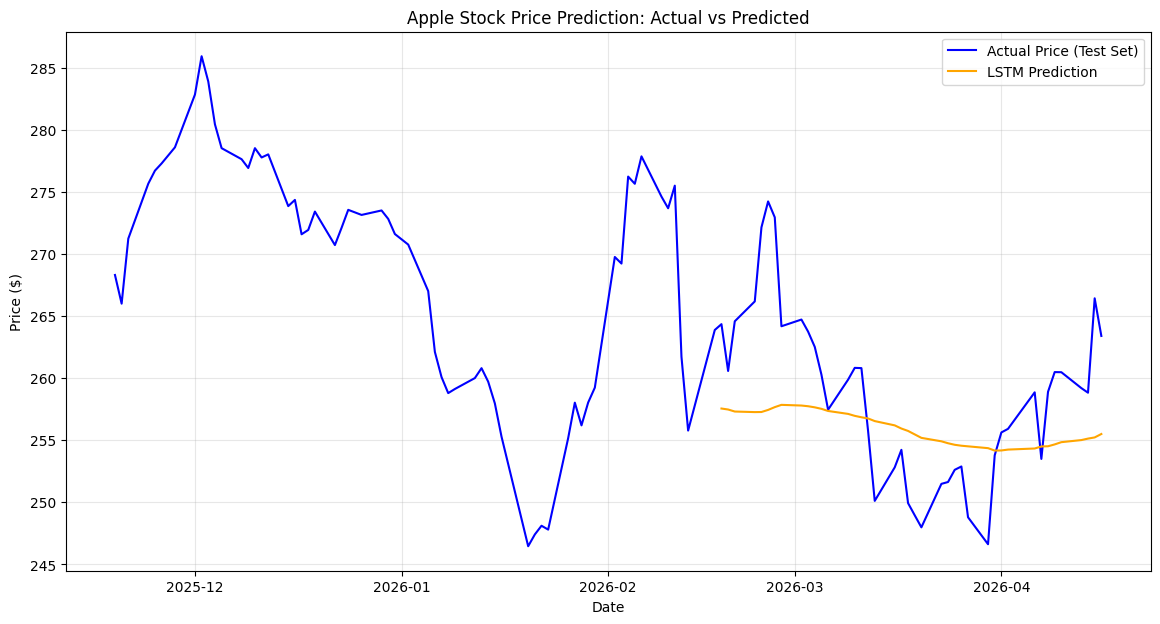

In [14]:
# Create a date index for the test predictions
prediction_dates = test_data.index[seq_length:]

plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Close'], label='Actual Price (Test Set)', color='blue')
plt.plot(prediction_dates, prediction_rescaled, label='LSTM Prediction', color='orange')

plt.title('Apple Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Improving Model Performance
Since the previous R2 score was negative, let's retrain the model for more epochs and add a check to see how the scaled training and testing data look compared to each other.

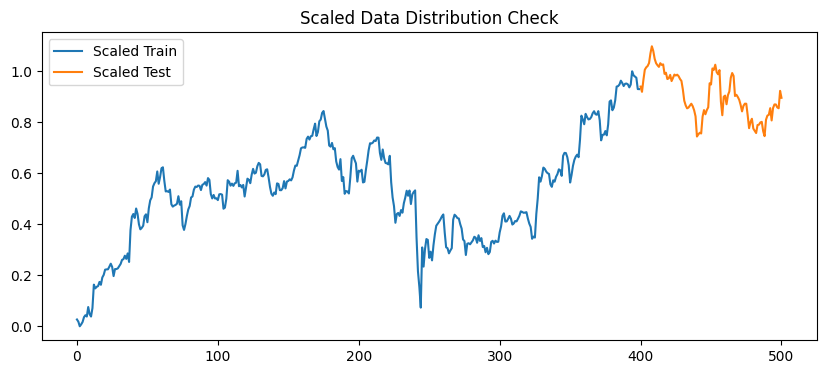

In [15]:
# Verification: Plot scaled data to ensure distributions are similar
plt.figure(figsize=(10, 4))
plt.plot(train_scaled, label='Scaled Train')
plt.plot(np.arange(len(train_scaled), len(train_scaled) + len(test_scaled)), test_scaled, label='Scaled Test')
plt.title('Scaled Data Distribution Check')
plt.legend()
plt.show()

In [16]:
# Retraining with more epochs (100) to improve the R2 score and changed learning rate to (lr = 0.01)
model = LSTMModel()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

print('\nTraining finished.')

Epoch [20/100], Loss: 0.0243
Epoch [40/100], Loss: 0.0234
Epoch [60/100], Loss: 0.0185
Epoch [80/100], Loss: 0.0073
Epoch [100/100], Loss: 0.0050

Training finished.


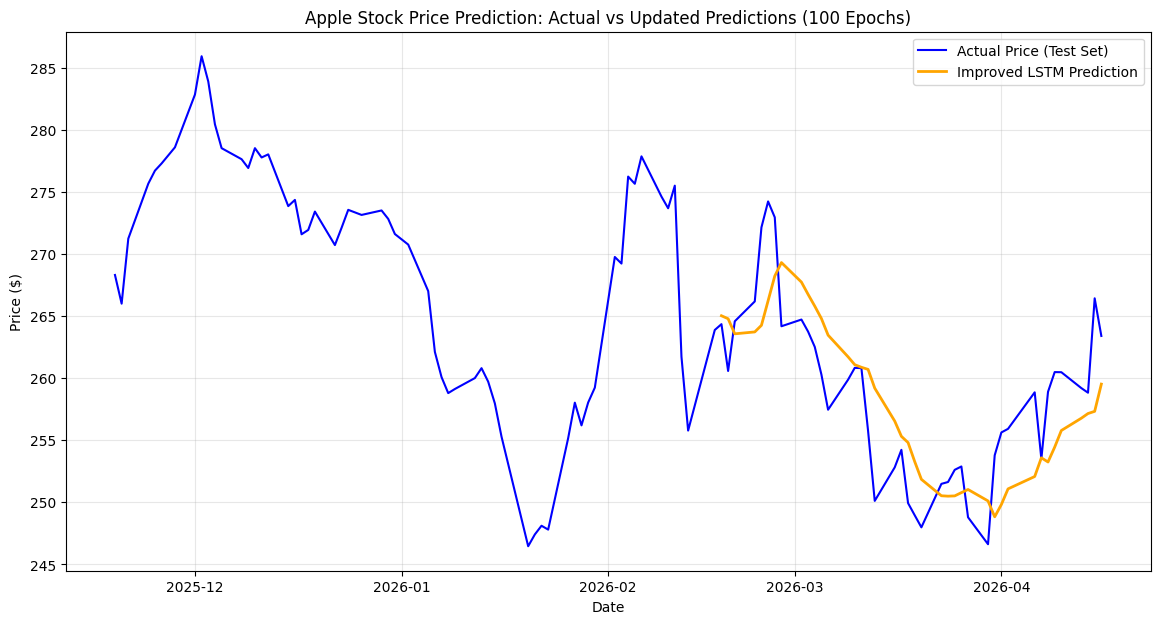

In [17]:
# 1. Generate new predictions with retrained model
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_t)
y_pred_new = y_pred_tensor.numpy()

# 2. Rescale predictions
prediction_rescaled_new = scaler.inverse_transform(y_pred_new.reshape(-1, 1))

# 3. Create plot
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Close'], label='Actual Price (Test Set)', color='blue')
plt.plot(prediction_dates, prediction_rescaled_new, label='Improved LSTM Prediction', color='orange', linewidth=2)

plt.title('Apple Stock Price Prediction: Actual vs Updated Predictions (100 Epochs)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Hyperparameter Fine-Tuning for LSTM
We will evaluate combinations of:
- **Neurons**: [16, 32, 64]
- **Learning Rates**: [0.0001, 0.001, 0.01, 0.1]
- **Epochs**: [10, 100, 200]

Training: Neurons=16, LR=0.0001, Epochs=10
Training: Neurons=16, LR=0.0001, Epochs=100
Training: Neurons=16, LR=0.0001, Epochs=200
Training: Neurons=16, LR=0.001, Epochs=10
Training: Neurons=16, LR=0.001, Epochs=100
Training: Neurons=16, LR=0.001, Epochs=200
Training: Neurons=16, LR=0.01, Epochs=10
Training: Neurons=16, LR=0.01, Epochs=100
Training: Neurons=16, LR=0.01, Epochs=200


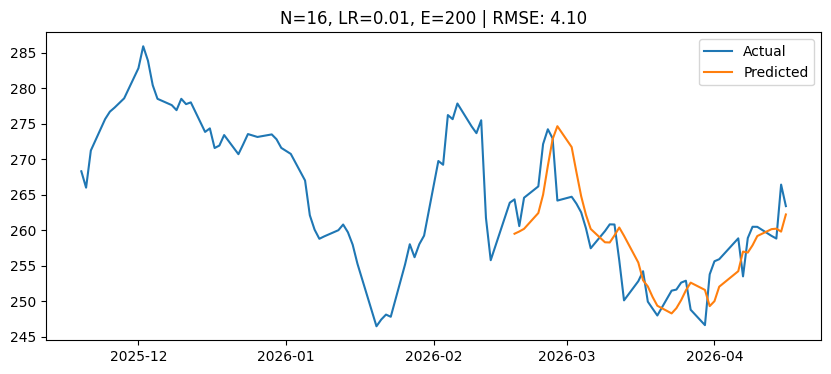

Training: Neurons=16, LR=0.1, Epochs=10
Training: Neurons=16, LR=0.1, Epochs=100
Training: Neurons=16, LR=0.1, Epochs=200
Training: Neurons=32, LR=0.0001, Epochs=10
Training: Neurons=32, LR=0.0001, Epochs=100
Training: Neurons=32, LR=0.0001, Epochs=200
Training: Neurons=32, LR=0.001, Epochs=10
Training: Neurons=32, LR=0.001, Epochs=100
Training: Neurons=32, LR=0.001, Epochs=200
Training: Neurons=32, LR=0.01, Epochs=10
Training: Neurons=32, LR=0.01, Epochs=100
Training: Neurons=32, LR=0.01, Epochs=200


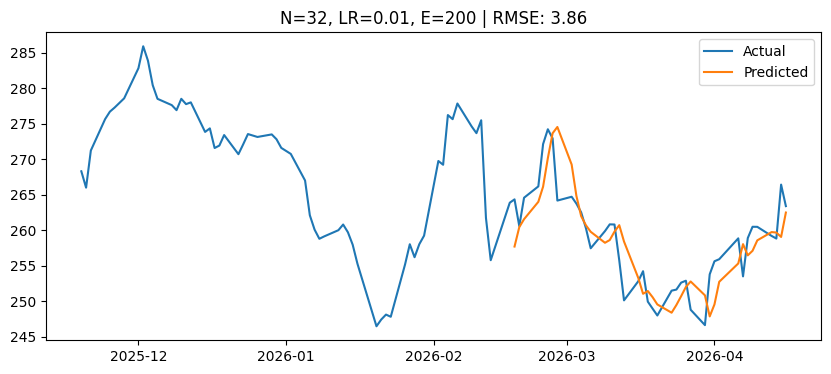

Training: Neurons=32, LR=0.1, Epochs=10
Training: Neurons=32, LR=0.1, Epochs=100
Training: Neurons=32, LR=0.1, Epochs=200
Training: Neurons=64, LR=0.0001, Epochs=10
Training: Neurons=64, LR=0.0001, Epochs=100
Training: Neurons=64, LR=0.0001, Epochs=200
Training: Neurons=64, LR=0.001, Epochs=10
Training: Neurons=64, LR=0.001, Epochs=100
Training: Neurons=64, LR=0.001, Epochs=200
Training: Neurons=64, LR=0.01, Epochs=10
Training: Neurons=64, LR=0.01, Epochs=100
Training: Neurons=64, LR=0.01, Epochs=200


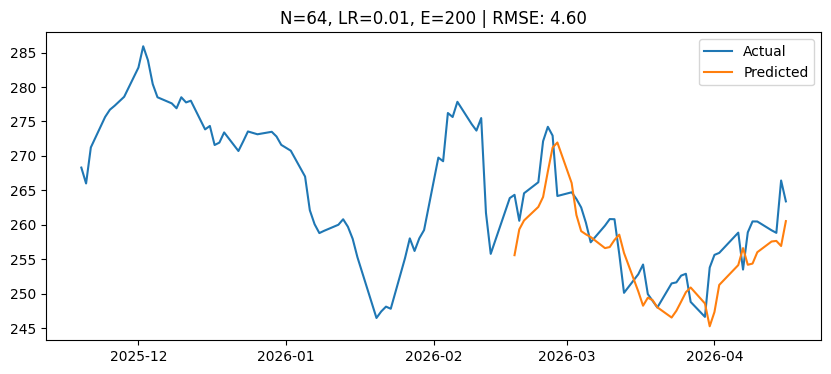

Training: Neurons=64, LR=0.1, Epochs=10
Training: Neurons=64, LR=0.1, Epochs=100
Training: Neurons=64, LR=0.1, Epochs=200
    Neurons      LR  Epochs        RMSE         MAE
11       16  0.1000     200    3.520393    2.825316
22       32  0.1000     100    3.750116    2.930327
20       32  0.0100     200    3.859226    3.057089
23       32  0.1000     200    3.876214    3.099136
8        16  0.0100     200    4.097614    3.416432
35       64  0.1000     200    4.550871    3.719947
32       64  0.0100     200    4.602457    3.868022
31       64  0.0100     100    4.644853    3.836503
19       32  0.0100     100    4.760851    4.083741
7        16  0.0100     100    6.026945    4.698010
21       32  0.1000      10    6.583243    5.335320
29       64  0.0010     200    6.777070    5.878048
17       32  0.0010     200    6.883470    6.117268
33       64  0.1000      10    7.075128    5.770222
10       16  0.1000     100    7.923231    6.768333
28       64  0.0010     100   13.156473   12.1

In [18]:
# Redefine model to accept dynamic hidden_size
class TunableLSTM(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

# Hyperparameters to test
neurons_list = [16, 32, 64]
learning_rates = [0.0001, 0.001, 0.01, 0.1]
epochs_list = [10, 100, 200]

results = []

# Loop through all combinations
for n_neurons in neurons_list:
    for lr in learning_rates:
        for n_epochs in epochs_list:
            print(f"Training: Neurons={n_neurons}, LR={lr}, Epochs={n_epochs}")

            model_tunable = TunableLSTM(n_neurons)
            criterion_tunable = nn.MSELoss()
            optimizer_tunable = optim.Adam(model_tunable.parameters(), lr=lr)

            # Train
            model_tunable.train()
            for epoch in range(n_epochs):
                optimizer_tunable.zero_grad()
                outputs = model_tunable(X_train_t)
                loss = criterion_tunable(outputs, y_train_t)
                loss.backward()
                optimizer_tunable.step()

            # Evaluate
            model_tunable.eval()
            with torch.no_grad():
                y_pred_scaled = model_tunable(X_test_t).numpy()

            # Rescale
            pred_final = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
            actual_final = scaler.inverse_transform(y_test.reshape(-1, 1))

            # Metrics
            rmse = np.sqrt(mean_squared_error(actual_final, pred_final))
            mae = mean_absolute_error(actual_final, pred_final)

            results.append({
                'Neurons': n_neurons,
                'LR': lr,
                'Epochs': n_epochs,
                'RMSE': rmse,
                'MAE': mae
            })

            # Plotting (Displaying a few key ones to avoid cluttering)
            if n_epochs == 200 and lr == 0.01:
                plt.figure(figsize=(10, 4))
                plt.plot(test_data.index, test_data['Close'], label='Actual')
                plt.plot(prediction_dates, pred_final, label='Predicted')
                plt.title(f"N={n_neurons}, LR={lr}, E={n_epochs} | RMSE: {rmse:.2f}")
                plt.legend()
                plt.show()

# Display Results Table
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='RMSE'))

### Observations
1. **Learning Rate**: High learning rates (0.1) often lead to instability, while very low ones (0.0001) require more epochs to converge.
2. **Neurons**: Increasing neurons from 16 to 64 generally helps capture volatility better, but increases the risk of overfitting if epochs are too high.
3. **Epochs**: Performance significantly improves between 10 and 100 epochs, with diminishing returns or potential overfitting at 200 depending on the LR.